# AI vs Human Text Classification & Detection using Sentence Embeddings: Model Benchmark

Dataset : https://www.kaggle.com/datasets/hasanyiitakbulut/ai-and-human-text-dataset

#  Step 0 - import library 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



# Step 1 - Load dataset

In [2]:
dataset =  pd.read_csv("/kaggle/input/datasets/hasanyiitakbulut/ai-and-human-text-dataset/data_for_preprocessing.csv")
dataset.head(10) # pring 10 samples

,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human
5,5,INTENT is an evidence-based smoking preventio...,Human
6,6,Traditional opera is continuously involved in...,Human
7,7,This research analyzes how Mughal miniature pa...,AI
8,8,This study examines the dialectology of the Bl...,AI
9,9,Understanding dream formation is scientificall...,AI


In [3]:
dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6069 entries, 0 to 6068
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6069 non-null   int64 
 1   Text        6069 non-null   object
 2   Author      6069 non-null   object
dtypes: int64(1), object(2)
memory usage: 142.4+ KB


,Unnamed: 0
count,6069.000000
mean,3034.000000
std,1752.113723
min,0.000000
25%,1517.000000
50%,3034.000000
75%,4551.000000
max,6068.000000


# Step 2 - Data Preprocessing

In [4]:
print(f"duplicate count: {dataset.duplicated().sum()}") # check for duplicate 
dataset.isnull().sum() # check for miision values

duplicate count: 0


Unnamed: 0    0
Text          0
Author        0
dtype: int64

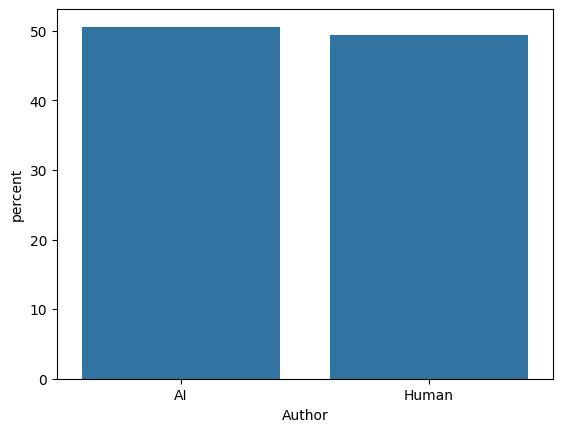

In [5]:
# to see how the data is balance
sns.countplot(data=dataset, x="Author",stat="percent")
plt.show()

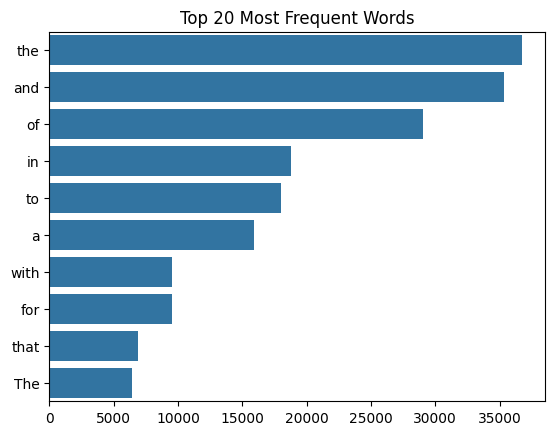

In [6]:
# Count top 10 words - to see if leakage e.g "generated", "AI" text is being mensions in the data
word_freq = Counter(" ".join(dataset["Text"]).split()).most_common(10)

# Unzip into words and counts
words, counts = zip(*word_freq)

# Plot
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Frequent Words")
plt.show()

Largest text in 'Text column' has : 4901 count


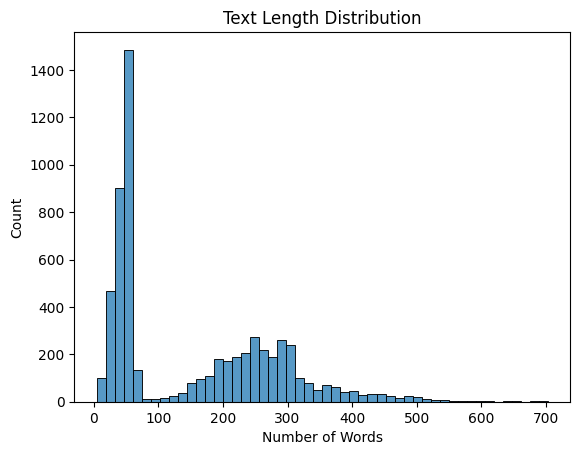

In [7]:
print(f"Largest text in 'Text column' has : {dataset['Text'].astype(str).map(len).max()} count") # largest sentence length in 'text' column
dataset["text_length"] = dataset["Text"].str.split().str.len()
sns.histplot(dataset["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

In [8]:
# encode the terget lebel
le = LabelEncoder()
dataset["Author"] = le.fit_transform(dataset["Author"])
dataset.head()

,Unnamed: 0,Text,Author,text_length
0,0,This study investigates the chemical compositi...,0,17
1,1,This study explores the cultural history of oi...,0,23
2,2,Isolation of human peripheral blood mononucle...,1,346
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,1,119
4,4,"Within volleyball, performance analysis is em...",1,204


In [9]:
X = dataset['Text']
y = dataset['Author']

In [10]:
# spliting the dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3  - Text Embeddings 

In [11]:
# Create meaningful numerical embeddings of the texts.

# Check if GPU is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# 3. Convert text to embeddings
X_train_embeddings = model.encode(X_train.tolist(), show_progress_bar=True, batch_size=128)
X_test_embeddings = model.encode(X_test.tolist(), show_progress_bar=True, batch_size=128)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [12]:
X_train_embeddings.shape, X_test_embeddings.shape


((4855, 384), (1214, 384))


TSNE Graph Interpretation Notes

1 - Overlapping dots → the data points are very similar (model can’t clearly distinguish them)

2 - Tight clusters → points in the same group share strong similarity (same class or pattern)

3 - Dots far away from their cluster → likely outliers or unusual samples

4 - Well-separated clusters → classes are easily distinguishable (good for classification)

5 - Mixed clusters (colors blended) → features are not strong enough to separate classes



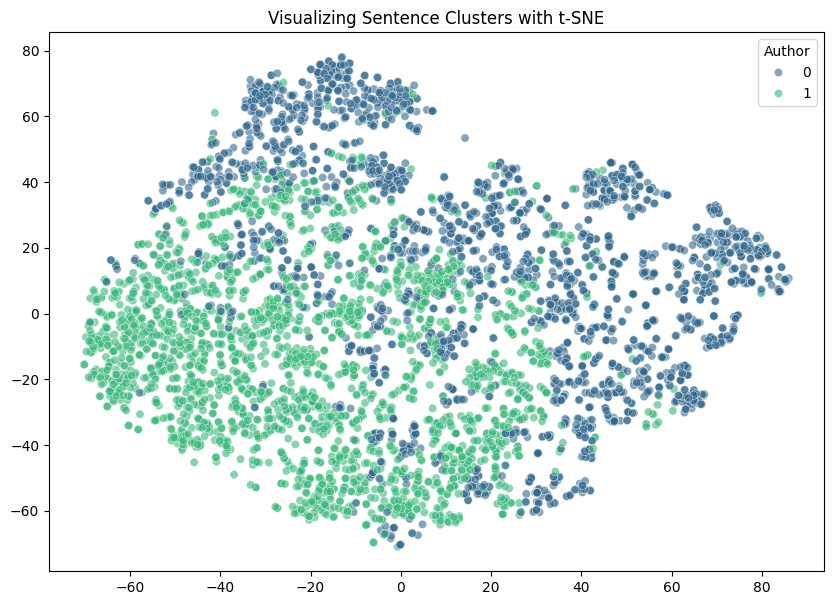

In [13]:
# 1. Reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_train_embeddings)

tsne_comment = """
TSNE Graph Interpretation Notes

1 - Overlapping dots → the data points are very similar (model can’t clearly distinguish them)

2 - Tight clusters → points in the same group share strong similarity (same class or pattern)

3 - Dots far away from their cluster → likely outliers or unusual samples

4 - Well-separated clusters → classes are easily distinguishable (good for classification)

5 - Mixed clusters (colors blended) → features are not strong enough to separate classes
"""

print(tsne_comment)
# 2. Plot it
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=y_train, palette='viridis', alpha=0.6)
plt.title("Visualizing Sentence Clusters with t-SNE")
plt.show()


In [14]:
iso = IsolationForest(contamination=0.05)

# Train on training data
iso.fit(X_train_embeddings)

# Predict on test data
labels = iso.predict(X_test_embeddings)

# Get outliers from test set
outliers = X_test[labels == -1]

# Get correct indices relative to test set
outlier_idx = np.where(labels == -1)[0]

# Print actual text from TEST set (outliers)
#print(X_test.iloc[outlier_idx])
print(f"found :{len(X_test.iloc[outlier_idx])} outliers")

found :64 outliers


In [15]:
#manual visulaization of outliers
print(X_test[2797])
print(X_test[5946])
print(X_test[2989])

# remove outliers
#clean_X = X_test[labels != -1]

Smart concrete that generates power. We embedded "Triboelectric Nanogenerators" (TENGs) into highway pavement. The vibration and pressure of passing vehicles generate electricity. A 1 km test strip produced enough energy to power streetlights and traffic sensors, harvesting waste mechanical energy.
We investigate the internationalization of higher education in Turkey, analyzing the government's strategy to attract foreign students.
Superconductors for maglev. We designed a "Flux-Pinning" bearing using High-Temperature Superconductor (HTS) bulks. The bearing supports a rotating flywheel energy storage system. The passive magnetic stability eliminates the need for active control and reduces friction losses to near zero, enabling long-term energy storage.


# Step 4 - Modeling, Evaluation & Benchmarking

In [16]:
# models init
models = {
    "Logistic Regression": LogisticRegression(max_iter=100),
    "SVM": LinearSVC(dual='auto'),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(n_estimators=200, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=200, verbose=-1)
}


results = []

for name, model in models.items():
    #Cross-validation on training set (F1 score)
    cv_scores = cross_val_score(model, X_train_embeddings, y_train, cv=5, scoring="f1")
    mean_cv = cv_scores.mean()
    
    #training
    model.fit(X_train_embeddings, y_train)
    
    #Predict on test
    preds = model.predict(X_test_embeddings)
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 3),
        "CV F1": round(mean_cv, 3),  # mean CV score
        "Precision": round(precision_score(y_test, preds), 3),
        "Recall": round(recall_score(y_test, preds), 3),
        "F1 Score": round(f1_score(y_test, preds), 3)
    })



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [17]:
# Make DataFrame , sort by F1 Score
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

# Apply style: blue-white gradient
styled_df = (results_df.style.background_gradient(cmap="Blues"))

styled_df

,Model,Accuracy,CV F1,Precision,Recall,F1 Score
1,SVM,0.989000,0.988000,0.995000,0.983000,0.989000
4,LightGBM,0.989000,0.983000,0.992000,0.987000,0.989000
3,XGBoost,0.988000,0.983000,0.992000,0.985000,0.988000
2,Random Forest,0.988000,0.981000,0.997000,0.978000,0.987000
0,Logistic Regression,0.982000,0.976000,0.988000,0.975000,0.982000
